<a href="https://colab.research.google.com/github/adityajain9756-rgb/ecommerce-sales-analysis/blob/main/EDA_aditya_amazon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -Exploratory Data Analysis of Amazon E-Commerce Sales



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Name** - Aditya Jain


# **Project Summary -**

This project performs **Exploratory Data Analysis (EDA)** on an Amazon Sales Report dataset to gain insights into sales performance, product demand, order fulfillment, and customer purchasing trends. The analysis includes data cleaning, handling missing values, identifying patterns, and visualizing key business metrics.

The project aims to uncover valuable insights such as top-performing product categories, sales trends, regional performance, order status distribution, and the impact of fulfillment methods. These findings can help improve inventory management, optimize sales strategies, and support data-driven business decisions for an e-commerce business.


# **GitHub Link -**

https://github.com/adityajain9756-rgb/ecommerce-sales-analysis.git

# **Problem Statement**


In the highly competitive e-commerce industry, understanding sales performance and customer purchasing behavior is essential for business growth. Amazon generates a large volume of transactional data containing information about orders, products, fulfillment methods, shipping locations, and sales. However, raw data alone does not provide actionable insights.

The challenge is to analyze this sales data to identify sales trends, top-performing product categories, regional demand, order fulfillment efficiency, and factors influencing business performance. By performing Exploratory Data Analysis (EDA), the objective is to transform raw transactional data into meaningful insights that can support better decision-making, improve operational efficiency, optimize inventory management, and enhance customer satisfaction.


#### **Define Your Business Objective?**

The primary objective of this project is to analyze Amazon sales data to understand customer purchasing patterns, product performance, sales trends, and order fulfillment efficiency. Through Exploratory Data Analysis (EDA), the project aims to identify top-selling product categories, evaluate regional sales performance, analyze order status and fulfillment methods, and uncover key factors influencing sales. The insights generated from this analysis will help support data-driven decisions for improving inventory management, optimizing sales strategies, enhancing customer satisfaction, and increasing overall business performance.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

### Dataset Loading

In [2]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Amazon Sale Report.csv",low_memory=False)
df.drop(columns=["Unnamed: 22"], inplace=True) #as this column is completelly empty

Mounted at /content/drive


### Dataset First View

In [3]:
# Dataset First Look
# Display all columns
pd.set_option('display.max_columns', None)
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
df.shape

(128975, 23)

### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
duplicate_row_count = df.duplicated().sum()
print(duplicate_row_count)

0


#### Missing Values/Null Values

In [11]:
# Missing Values/Null Values Count
missing_values = df.isnull().sum()
print(missing_values)

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
dtype: int64


Text(0, 0.5, 'Columns')

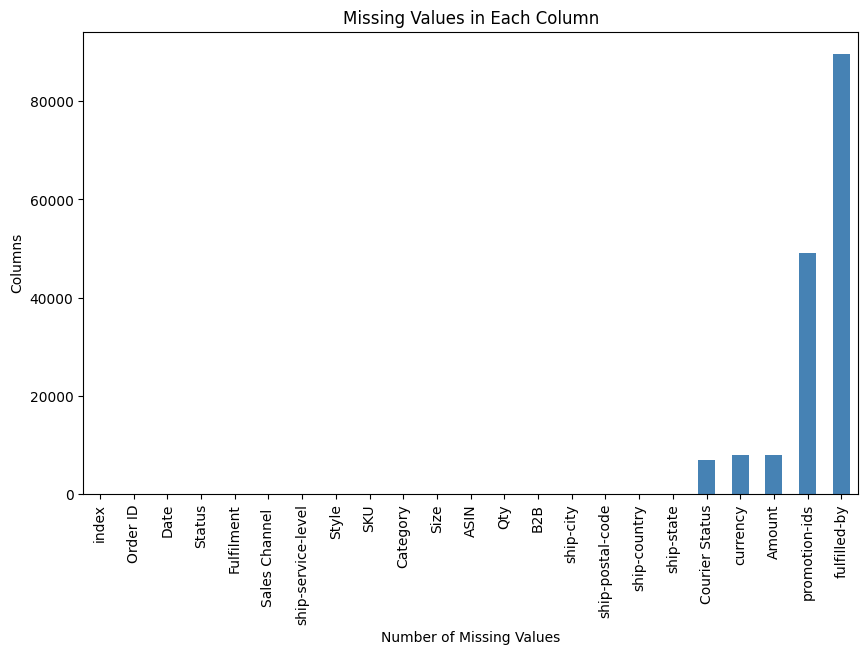

In [13]:
# Visualizing the missing values
plt.figure(figsize=(10,6))
missing_values.sort_values().plot(kind='bar', color='steelblue')

plt.title('Missing Values in Each Column')
plt.xlabel('Number of Missing Values')
plt.ylabel('Columns')


### What did you know about your dataset?

* The dataset contains Amazon e-commerce sales transaction records, providing information about orders, products, sales amounts, fulfillment methods, shipping details, and order status.
* It consists of approximately **128,000+ records** and **24 columns**, making it suitable for detailed exploratory data analysis.
* The dataset includes both **categorical variables** (such as Category, Status, Fulfilment, Ship State, Ship City, Size, and Courier Status) and **numerical variables** (such as Quantity and Amount).
* Some columns contain missing values, particularly in shipping, courier, and sales-related fields, which require appropriate data cleaning before analysis.
* The dataset also contains an unnecessary column (`Unnamed: 22`) that is removed during preprocessing.
* Date information is available and can be used to analyze sales trends over time.
* Overall, the dataset provides sufficient information to analyze product performance, sales trends, regional demand, order fulfillment efficiency, and customer purchasing patterns, enabling meaningful business insights and recommendations.
Answer Here

## ***2. Understanding Variables***

In [16]:
# Dataset Columns
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by'],
      dtype='object')

In [19]:
# Dataset Describe
df.describe()

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


### Variables Description

* The dataset contains 128,975 order records.
* Customers usually purchase one item per order, as the median quantity is 1.
* The average order value is approximately ₹648.56, with values ranging from ₹0 to ₹5,584, indicating variation in purchase amounts.
* Shipping postal codes vary widely across the dataset, indicating that orders are placed from multiple geographic regions.
* The presence of 0 values in Qty and Amount may indicate cancelled, returned, or invalid orders and should be investigated during data cleaning.

### Check Unique Values for each variable.

In [20]:
# Check Unique Values for each variable.
for column in df.columns:
    unique_count = df[column].nunique()
    print(f"Column '{column}' has {unique_count} unique values.")

Column 'index' has 128975 unique values.
Column 'Order ID' has 120378 unique values.
Column 'Date' has 91 unique values.
Column 'Status' has 13 unique values.
Column 'Fulfilment' has 2 unique values.
Column 'Sales Channel ' has 2 unique values.
Column 'ship-service-level' has 2 unique values.
Column 'Style' has 1377 unique values.
Column 'SKU' has 7195 unique values.
Column 'Category' has 9 unique values.
Column 'Size' has 11 unique values.
Column 'ASIN' has 7190 unique values.
Column 'Courier Status' has 3 unique values.
Column 'Qty' has 10 unique values.
Column 'currency' has 1 unique values.
Column 'Amount' has 1410 unique values.
Column 'ship-city' has 8955 unique values.
Column 'ship-state' has 69 unique values.
Column 'ship-postal-code' has 9459 unique values.
Column 'ship-country' has 1 unique values.
Column 'promotion-ids' has 5787 unique values.
Column 'B2B' has 2 unique values.
Column 'fulfilled-by' has 1 unique values.


## 3. ***Data Wrangling***

### Data Wrangling Code

In [36]:
#Code to make dataset analysis ready.

# Create a copy of the dataset
df_clean = df.copy()

# Convert Date column into datetime format
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%m-%d-%y')

# Remove duplicate records
df_clean.drop_duplicates(inplace=True)

# Fill missing values
df_clean['Courier Status'] = df_clean['Courier Status'].fillna('Unknown')
df_clean['currency'] = df_clean['currency'].fillna('INR')
df_clean['fulfilled-by'] = df_clean['fulfilled-by'].fillna('Unknown')

# Remove rows where sales amount is missing
df_clean.dropna(subset=['Amount'], inplace=True)

# Remove rows with missing shipping information
df_clean.dropna(subset=[
    'ship-city',
    'ship-state',
    'ship-postal-code',
    'ship-country'
], inplace=True)

# Reset index
df_clean.reset_index(drop=True, inplace=True)

# Verif missing values
df_clean.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


### What all manipulations have been done and insights found?

#### Manipulations
* Created a copy of the original dataset to preserve the raw data.
* Converted the Date column to datetime format for time-based analysis.
* Removed duplicate records to ensure data consistency.
* Handled missing values by filling Courier Status, currency, and fulfilled-by with appropriate values.
* Removed records with missing Amount and essential shipping information, as these are critical for sales and regional analysis.
* Reset the index after cleaning to maintain a well-structured dataset.

#### Insights:

* The dataset contained missing values in a few key columns that required preprocessing.
* Most missing values were concentrated in promotion-ids and fulfilled-by, while only a small number of records had missing shipping details.
* After data wrangling, the dataset became clean, consistent, and ready for reliable exploratory data analysis.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [ ]:
# Chart - 1 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

In [ ]:
# Chart - 2 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

In [ ]:
# Chart - 3 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

In [ ]:
# Chart - 4 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

In [ ]:
# Chart - 5 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

In [ ]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [ ]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [ ]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [ ]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [ ]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [ ]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [ ]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [ ]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [ ]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [ ]:
# Pair Plot visualization code

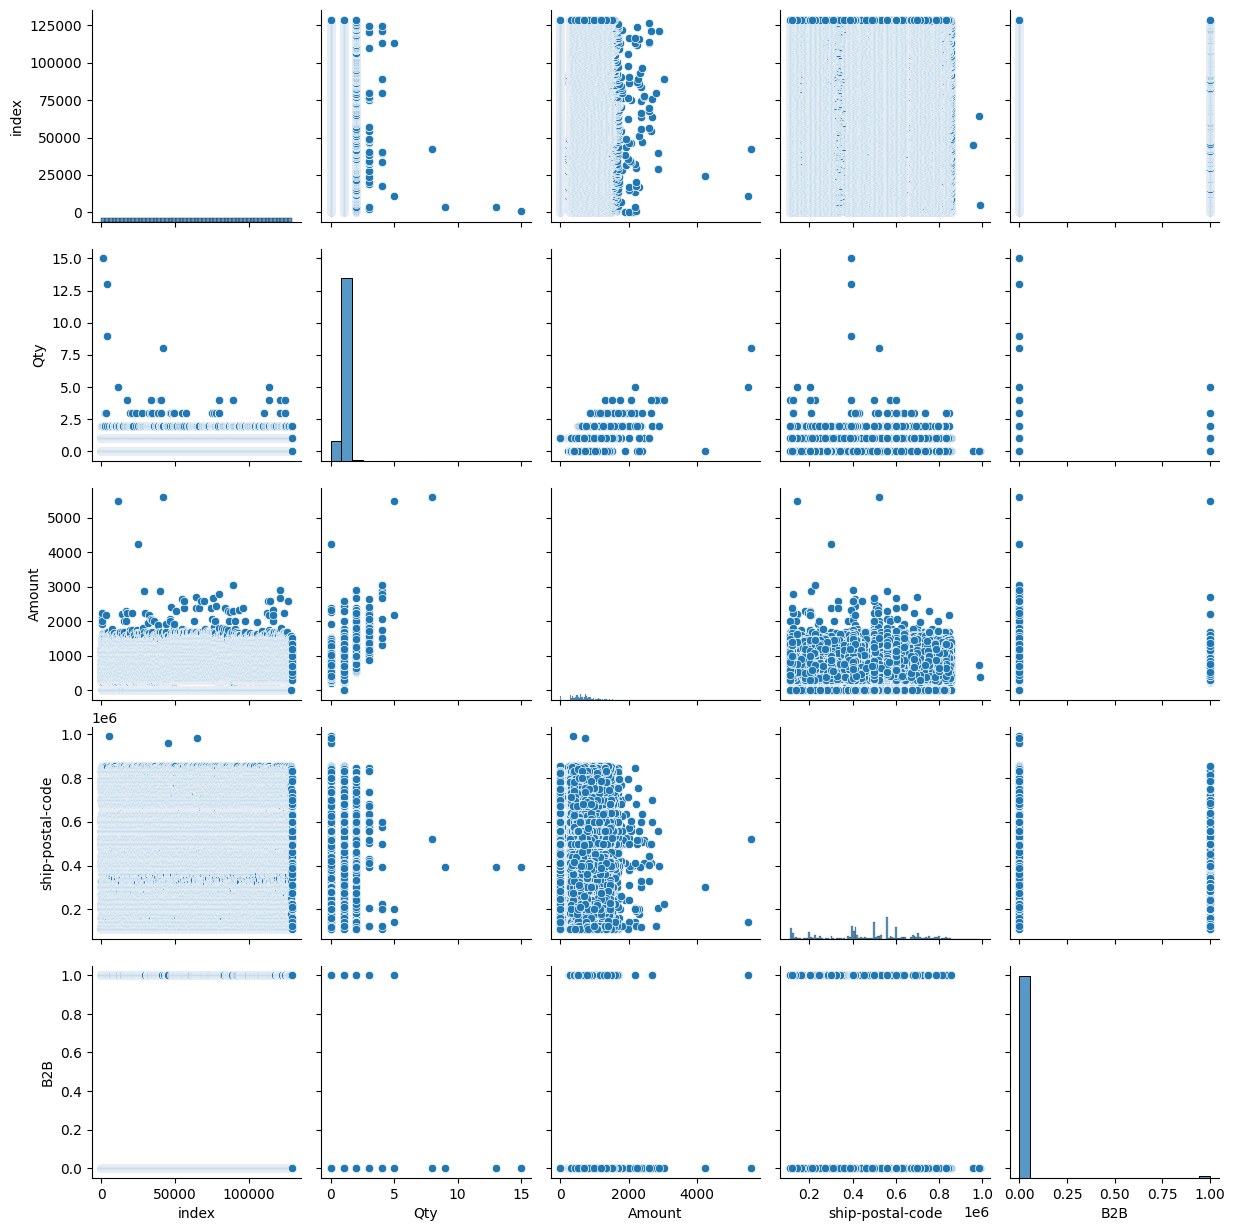

In [21]:
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***